In [3]:
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score,silhouette_samples

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

In [5]:
# Generate Sample Data
# this particular setting has 1 distinct cluster and 3 clusters placed close

X, y = make_blobs(n_samples=500,
                  n_features=2, 
                  centers=4, 
                  cluster_std=1,
                  center_box=(-10.0, 10.0), 
                  shuffle=True,     
                  random_state=42)

range_n_clusters = [2, 3, 4, 5, 6]

In [7]:
X

array([[ -7.68905443,   6.62034649],
       [ -9.57651383,  -6.93440446],
       [  6.82968177,   1.1648714 ],
       [ -2.90130578,   7.55077118],
       [ -5.67841327,  -7.28818497],
       [ -6.04929137,  -7.73619342],
       [ -6.27824322,   7.22746302],
       [ -6.60917037,  -6.9303477 ],
       [  3.57225841,   1.8307902 ],
       [ -7.50444577,  -6.85401854],
       [  3.99330595,   0.89162168],
       [ -1.35060204,   8.19360381],
       [  6.77291221,   0.02108188],
       [ -1.93830711,  10.14985177],
       [ -6.58985233,  -4.80470879],
       [  5.69830332,   0.2144302 ],
       [ -2.58120774,  10.01781903],
       [ -9.96104978,   7.70593266],
       [ -8.75604377,   8.38900329],
       [ -3.6155326 ,   7.8180795 ],
       [  3.24131126,   2.53613892],
       [ -2.30033403,   7.054616  ],
       [  5.2164358 ,   2.28441984],
       [ -7.27280373,   7.25777265],
       [ -9.28476137,   7.51761291],
       [ -6.48517505,  -7.30109407],
       [ -7.13460441,  -5.3761166 ],
 

In [8]:
y

array([3, 2, 1, 0, 2, 2, 3, 2, 1, 2, 1, 0, 1, 0, 2, 1, 0, 3, 3, 0, 1, 0,
       1, 3, 3, 2, 2, 3, 3, 0, 2, 0, 0, 0, 2, 2, 1, 1, 3, 3, 2, 1, 0, 0,
       0, 1, 1, 1, 2, 3, 2, 0, 3, 2, 1, 0, 0, 3, 2, 3, 3, 0, 2, 3, 1, 2,
       2, 3, 1, 2, 1, 2, 2, 3, 0, 3, 0, 2, 1, 0, 2, 1, 2, 0, 3, 3, 3, 3,
       1, 0, 3, 2, 1, 2, 1, 3, 0, 1, 0, 3, 1, 1, 1, 3, 3, 0, 0, 3, 0, 3,
       2, 3, 3, 3, 3, 2, 1, 3, 2, 2, 0, 1, 2, 1, 3, 1, 1, 2, 2, 3, 3, 1,
       1, 2, 1, 3, 3, 3, 1, 1, 2, 3, 1, 1, 2, 3, 3, 0, 0, 0, 2, 2, 1, 1,
       0, 3, 0, 3, 2, 2, 3, 3, 1, 1, 2, 0, 1, 2, 3, 3, 2, 0, 0, 3, 3, 0,
       0, 2, 2, 2, 0, 3, 0, 0, 3, 3, 0, 1, 0, 2, 2, 3, 3, 2, 0, 2, 0, 0,
       3, 2, 0, 0, 2, 3, 1, 3, 2, 1, 1, 3, 3, 2, 3, 0, 0, 2, 0, 3, 0, 1,
       1, 0, 3, 0, 1, 0, 0, 2, 2, 1, 2, 1, 0, 2, 3, 2, 0, 2, 1, 1, 1, 2,
       0, 1, 3, 3, 1, 0, 0, 2, 0, 0, 0, 0, 1, 1, 3, 0, 2, 1, 0, 0, 3, 0,
       2, 2, 1, 0, 1, 2, 0, 0, 1, 3, 0, 0, 0, 1, 3, 2, 0, 1, 1, 0, 2, 0,
       1, 3, 1, 2, 2, 0, 0, 1, 3, 1, 3, 1, 2, 1, 2,

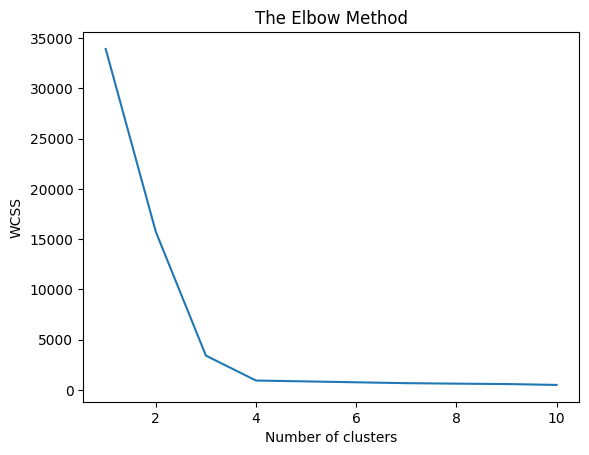

In [ ]:
from sklearn.cluster import KMeans

wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)
    # _inertia gives distance btw ceintroid and all other points

plt.plot(range(1, 11), wcss)
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

In [10]:
# Check K=4 is fine or not

clusters=KMeans(n_clusters=4, random_state=42)
cluster_labels=clusters.fit_predict(X)
print(cluster_labels)

[1 2 0 3 2 2 1 2 0 2 0 3 0 3 2 0 3 1 1 3 0 3 0 1 1 2 2 1 1 3 2 3 3 3 2 2 0
 0 1 1 2 0 3 3 3 0 0 0 2 1 2 3 1 2 0 3 3 1 2 1 1 3 2 1 0 2 2 1 0 2 0 2 2 1
 3 1 3 2 0 3 2 0 2 3 1 1 1 1 0 3 1 2 0 2 0 1 3 0 3 1 0 0 0 1 1 3 3 1 3 1 2
 1 1 1 1 2 0 1 2 2 3 0 2 0 1 0 0 2 2 1 1 0 0 2 0 1 1 1 0 0 2 1 0 0 2 1 1 3
 3 3 2 2 0 0 3 1 3 1 2 2 1 1 0 0 2 3 0 2 1 1 2 3 3 1 1 3 3 2 2 2 3 1 3 3 1
 1 3 0 3 2 2 1 1 2 3 2 3 3 1 2 3 3 2 1 0 1 2 0 0 1 1 2 1 3 3 2 3 1 3 0 0 3
 1 3 0 3 3 2 2 0 2 0 3 2 1 2 3 2 0 0 0 2 3 0 1 1 0 3 3 2 3 3 3 3 0 0 1 3 2
 0 3 3 1 3 2 2 0 3 0 2 3 3 0 1 3 3 3 0 1 2 3 0 0 3 2 3 0 1 0 2 2 3 3 0 1 0
 1 0 2 0 2 1 0 0 3 0 2 2 0 0 2 1 0 0 0 2 1 0 0 0 1 0 0 1 1 1 2 1 1 1 1 1 3
 1 0 1 3 3 1 0 0 0 3 3 2 3 2 3 0 2 2 0 2 1 1 2 1 3 2 3 0 3 2 2 1 0 2 0 0 1
 3 2 0 2 1 0 1 0 1 1 2 1 3 2 1 2 3 2 1 2 1 0 3 3 2 2 0 3 3 3 0 1 2 3 0 0 2
 1 2 2 2 3 0 2 3 0 3 3 0 3 0 3 1 2 0 3 2 1 3 0 0 2 2 2 1 2 0 1 3 3 1 0 1 0
 3 2 2 2 3 0 0 1 3 2 2 2 0 2 3 0 1 0 2 0 3 0 3 0 2 3 1 1 3 3 1 1 3 2 0 2 0
 3 1 1 3 2 1 1 0 1 1 3 1 

K = 2, Silhouette Score = 0.5955207405315346
K = 3, Silhouette Score = 0.7613478432173022
K = 4, Silhouette Score = 0.7911042588289479
K = 5, Silhouette Score = 0.6884073865467201
K = 6, Silhouette Score = 0.5596632788750456
K = 7, Silhouette Score = 0.4714293507290439
K = 8, Silhouette Score = 0.4433227653709222
K = 9, Silhouette Score = 0.4285349282465034
K = 10, Silhouette Score = 0.3453080147694503


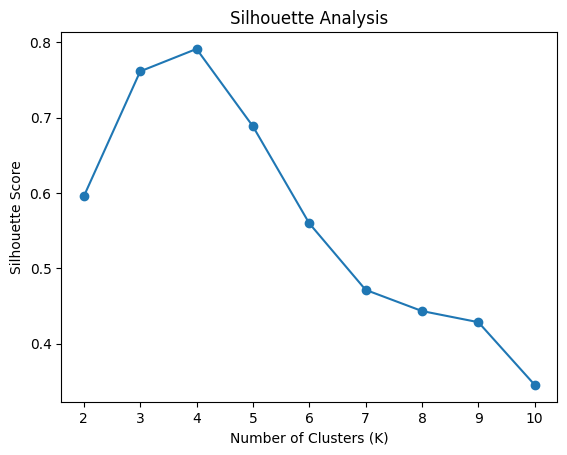

In [25]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

silhouette_coefficients = []

# K values
range_n_clusters = range(2, 11)

# try different K values
for k in range_n_clusters:

    kmeans = KMeans(
        n_clusters=k,
        init='k-means++',
        random_state=42
    )

    labels = kmeans.fit_predict(X)

    score = silhouette_score(X, labels)

    silhouette_coefficients.append(score)

    print(f"K = {k}, Silhouette Score = {score}")

# graph
plt.plot(range_n_clusters,
         silhouette_coefficients,
         marker='o')

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis")

plt.show()

Text(0, 0.5, 'Feature 2')

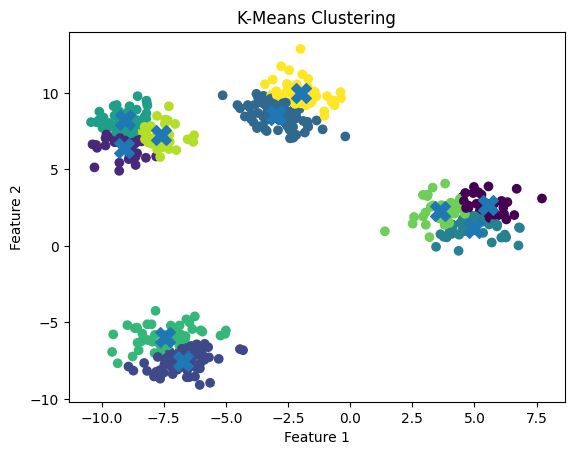

In [26]:
# plot data points
plt.scatter(
    X[:, 0],
    X[:, 1],
    c=labels
)

# plot centroids
plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    s=200,
    marker='X'
)

plt.title("K-Means Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")


In [27]:
print(kmeans.cluster_centers_)

[[ 5.54202903  2.6901675 ]
 [-9.11099232  6.40675002]
 [-6.70921046 -7.54259005]
 [-2.96289782  8.56781324]
 [ 4.99343956  1.13346764]
 [-9.05573391  8.23599185]
 [-7.43859656 -5.94725878]
 [ 3.63055479  2.26972406]
 [-7.62312818  7.24940347]
 [-1.98278258  9.99341598]]


In [28]:
import pandas as pd

df = pd.DataFrame(X, columns=['Feature1', 'Feature2'])

df['Cluster'] = labels

print(df.head())

   Feature1  Feature2  Cluster
0 -7.689054  6.620346        8
1 -9.576514 -6.934404        6
2  6.829682  1.164871        4
3 -2.901306  7.550771        3
4 -5.678413 -7.288185        2


In [29]:
df.groupby('Cluster').mean()

,Feature1,Feature2
Cluster,,
0,5.542029,2.690167
1,-9.110992,6.406750
2,-6.709210,-7.542590
3,-2.966647,8.556909
4,4.993440,1.133468
5,-9.055734,8.235992
6,-7.438597,-5.947259
7,3.630555,2.269724
8,-7.623128,7.249403
